# SaddlePointLinearSolver project - performance analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from datetime import datetime
import os

In [2]:
csv_path = '../tables/output.csv'

In [3]:
df = pd.read_csv(csv_path)

In [4]:
all_types = sorted(df['matrix-type'].unique())
all_types_name = "All Types"

types_2D = ['2DCartesian',
 '2DKershaw',
 '2DLocallyRefined',
 '2DPolygons',
 '2DQuadrangles',
 '2DTriangles' ]
types_2D_name = "2D"

types_3D = [
 '3DAssemblyMesh',
 '3DCheckerBoard',
 '3DHexa',
 '3DKershaw',
 '3DLocRaf',
 '3DPrism',
 '3DPrismHexa',
 '3DRandom',
 '3DTetra',
 '3DVoronoi']
types_3D_name = "3D"

In [5]:
SAVE_FIGURES = True

def safe_filename(title):
    # Replace anything that is not alphanumeric, '_' or '-' with '_'
    return re.sub(r'[^\w\-]', '_', title)

now_str = datetime.now().strftime('%Y-%m-%d_%H-%M')
subfolder = f"figures/{now_str}"
os.makedirs(subfolder, exist_ok=True)

In [6]:
# Generic plottiong function
def plot_metric_for_types(
    mesh_types,
    mesh_group_name,
    metric,
    y_label,
    title,
    apply_mean=False,
):
    for mtype in mesh_types:
        sub = df[(df['matrix-type'] == mtype) & (df['n-proc'] == 1)]
        if apply_mean:
            grouped = sub.groupby('matrix-size')[metric].mean()
            plt.scatter(sub['matrix-size'], sub['total-time'], marker='.', color=None)
            x, y = grouped.index, grouped.values
        else:
            x, y = sub['matrix-size'], sub[metric]
            indices = np.argsort(x)
            x = np.array(x)[indices]
            y = np.array(y)[indices]
        plt.plot(x, y, marker='o', label=mtype)

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Matrix size")
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend(title="Mesh type", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.grid(True, which="both", ls="--")
    if SAVE_FIGURES:
        plt.savefig(f'{subfolder}/{safe_filename(title)}.png')
    plt.show()

## Total error by mesh size and mesh type

In [7]:
def plot_error_for_types(mesh_types, mesh_group_name):
    title = f'Total Error vs. Matrix Size for Each Mesh Type in "{mesh_group_name}" Type List'
    plot_metric_for_types(metric="total-error",
                          y_label="Total error",
                          mesh_types=mesh_types,
                          mesh_group_name=mesh_group_name,
                          title=title)

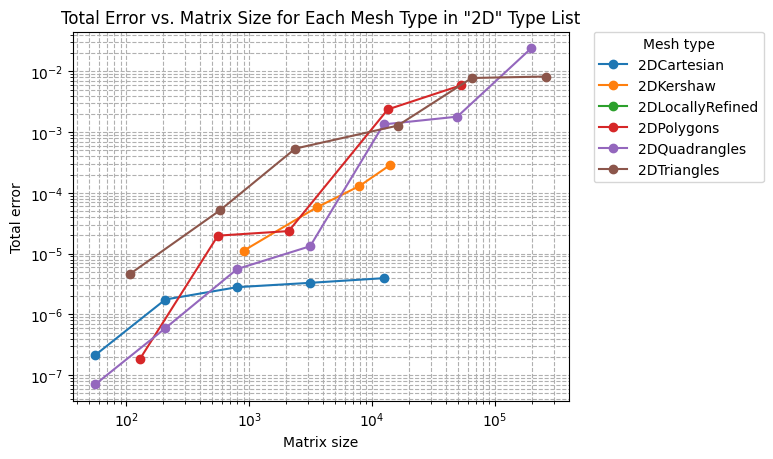

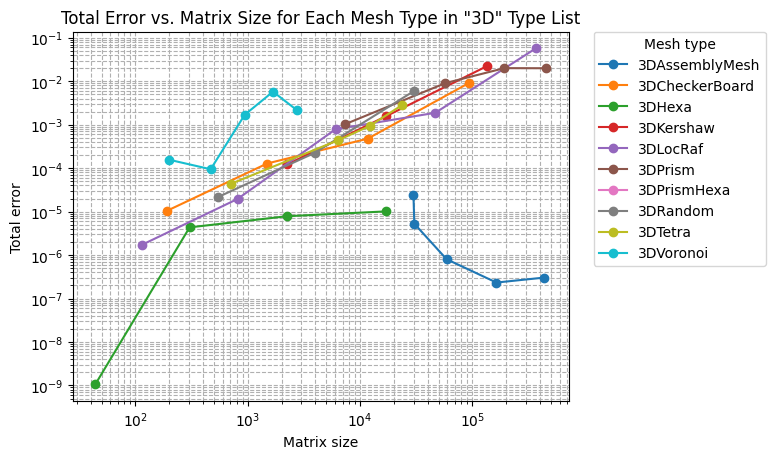

In [8]:
plot_error_for_types(types_2D, types_2D_name)
plot_error_for_types(types_3D, types_3D_name)

## Number of iterations by mesh size and mesh type

In [9]:
def plot_iter_for_types(mesh_types, mesh_group_name):
    title = f'Number of iterations vs. Matrix Size for Each Mesh Type in "{mesh_group_name}" Type List'
    plot_metric_for_types(metric="iter",
                          y_label="Number of iterations",
                          mesh_types=mesh_types,
                          mesh_group_name=mesh_group_name,
                          title=title)

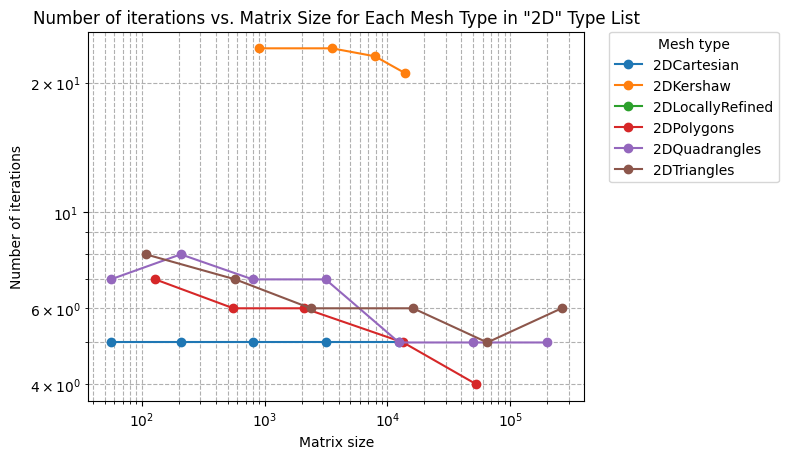

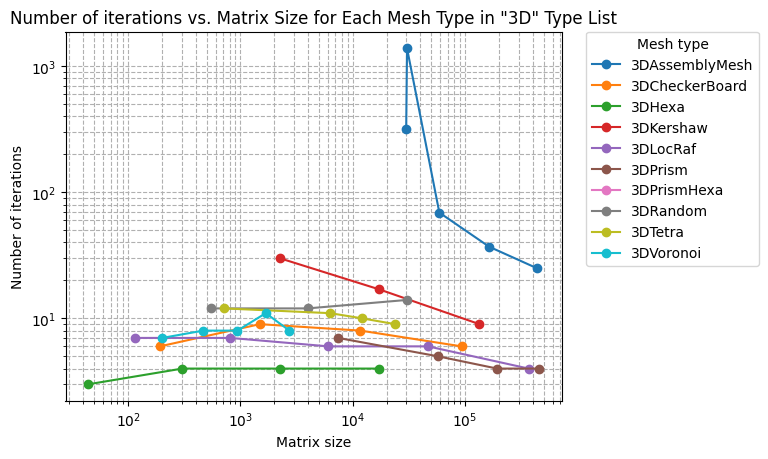

In [10]:
plot_iter_for_types(types_2D, types_2D_name)
plot_iter_for_types(types_3D, types_3D_name)

## Total Time by mesh size and mesh type (Sequential / 1 proc)

In [11]:
def plot_total_time_for_types(mesh_types, mesh_group_name):
    title = f'Total Time vs. Matrix Size for Each Mesh Type in "{mesh_group_name}" Type List'
    plot_metric_for_types(metric="total-time",
                          y_label="Total time",
                          mesh_types=mesh_types,
                          mesh_group_name=mesh_group_name,
                          title=title,
                          apply_mean=True)

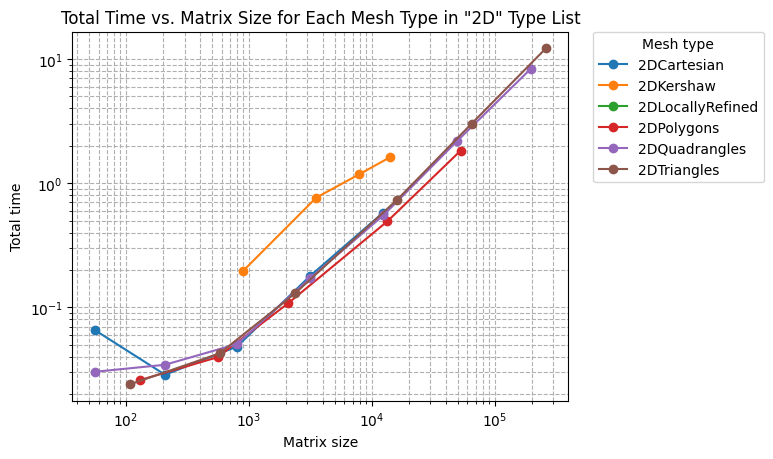

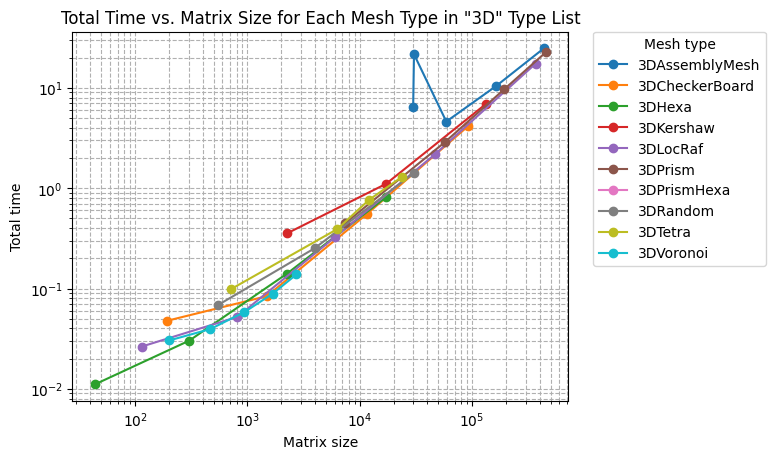

In [12]:
plot_total_time_for_types(types_2D, types_2D_name)
plot_total_time_for_types(types_3D, types_3D_name)

## Memory consumption by mesh size and mesh type

In [13]:
def plot_memory_consumption_for_types(mesh_types, mesh_group_name):
    title = f'Memory Consumption vs. Matrix Size for Each Mesh Type in "{mesh_group_name}" Type List'
    plot_metric_for_types(metric="memory-consumption",
                          y_label="Memory consumption",
                          mesh_types=mesh_types,
                          mesh_group_name=mesh_group_name,
                          title=title)

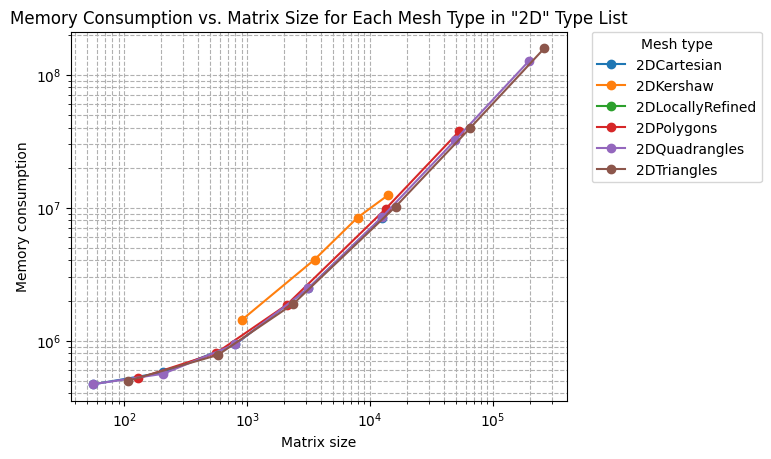

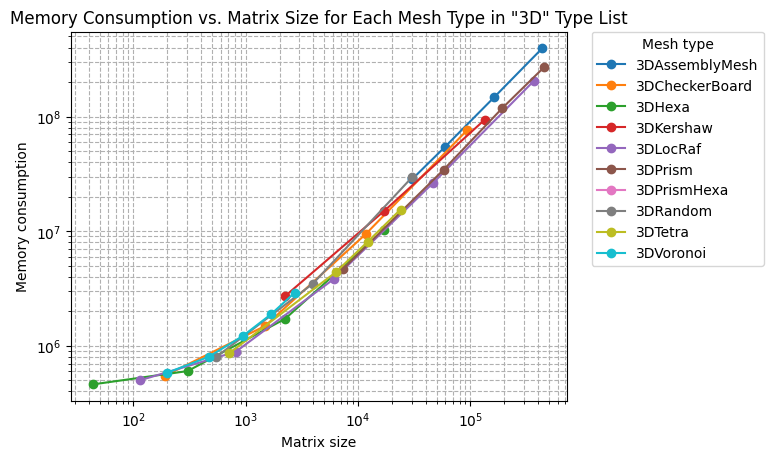

In [14]:
plot_memory_consumption_for_types(types_2D, types_2D_name)
plot_memory_consumption_for_types(types_3D, types_3D_name)

## Condition number by mesh size and mesh type

In [15]:
def plot_condition_number_for_types(mesh_types, mesh_group_name):
    title = f'Condition Number vs. Matrix Size for Each Mesh Type in "{mesh_group_name}" Type List'
    plot_metric_for_types(metric="condition-number",
                          y_label="Condition number",
                          mesh_types=mesh_types,
                          mesh_group_name=mesh_group_name,
                          title=title)

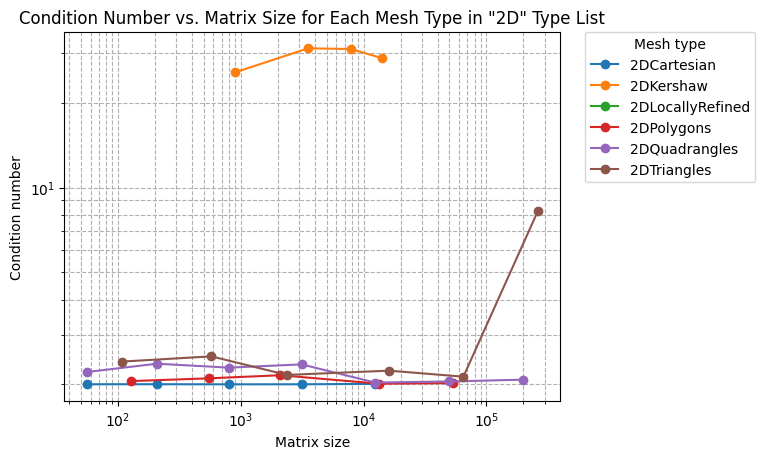

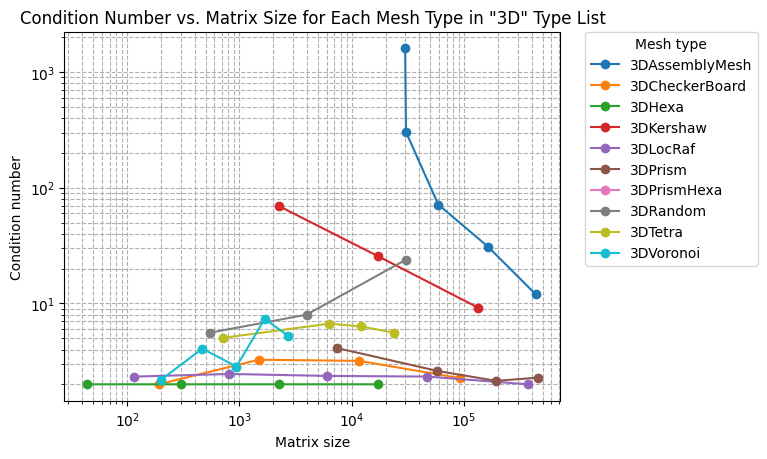

In [16]:
plot_condition_number_for_types(types_2D, types_2D_name)
plot_condition_number_for_types(types_3D, types_3D_name)

## Residual / Error ratio by mesh size and mesh type

In [17]:
def plot_residual_error_ratio_for_types(mesh_types, mesh_group_name):
    title = f'Residual / Error ratio vs. Matrix Size for Each Mesh Type in "{mesh_group_name}" Type List'
    plot_metric_for_types(metric="residual-error-ratio",
                          y_label="Ratio",
                          mesh_types=mesh_types,
                          mesh_group_name=mesh_group_name,
                          title=title)

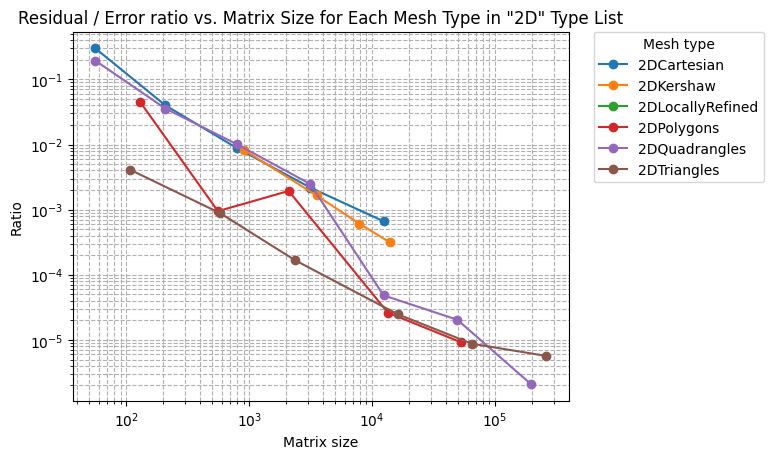

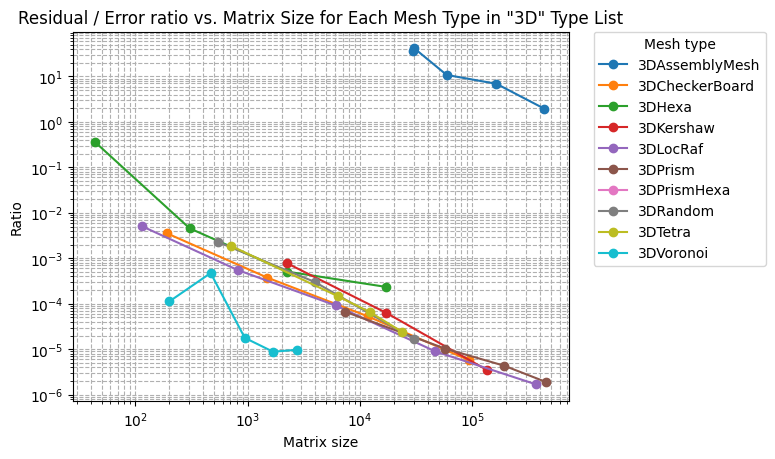

In [18]:
plot_residual_error_ratio_for_types(types_2D, types_2D_name)
plot_residual_error_ratio_for_types(types_3D, types_3D_name)

## Total Time by Matrix Size and Number of Processors for Each Mesh Type

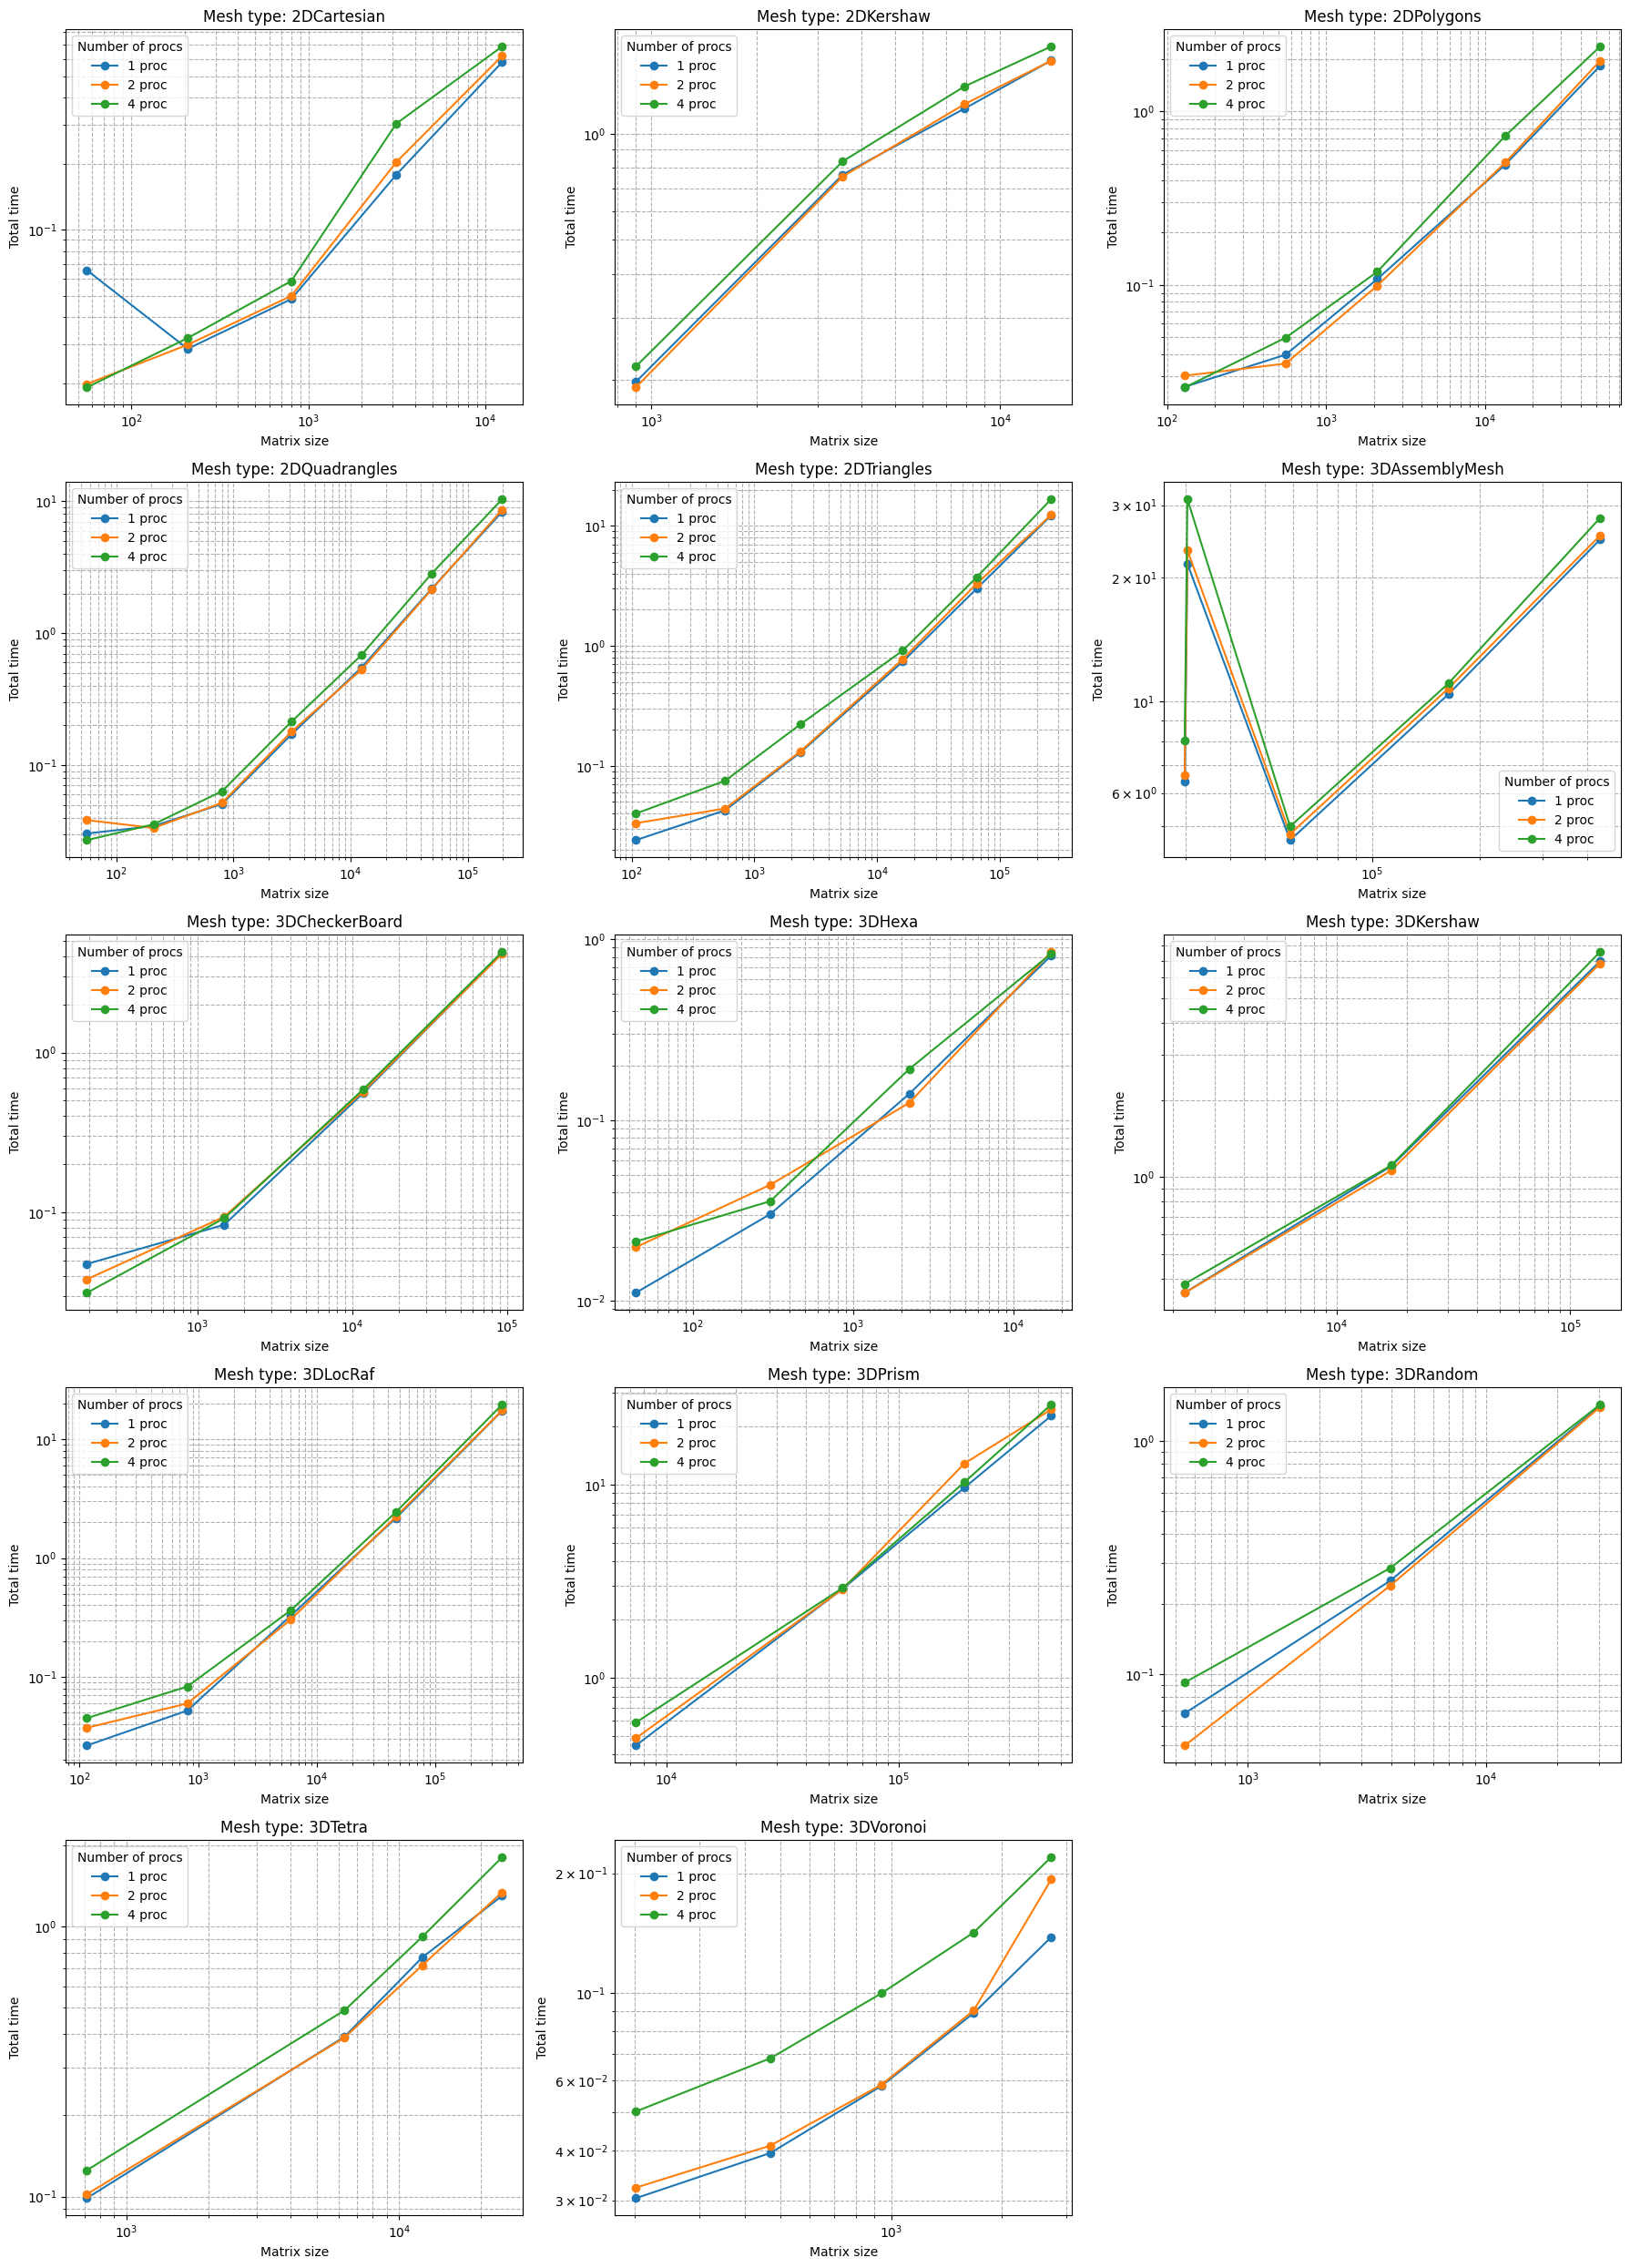

In [19]:
types_maillage = sorted(df['matrix-type'].unique())
n_types = len(types_maillage)

ncols = min(3, n_types)
nrows = int(np.ceil(n_types / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)

for idx, mtype in enumerate(types_maillage):
    row, col = divmod(idx, ncols)
    ax = axs[row, col]
    sub = df[df['matrix-type'] == mtype]
    for nproc in sorted(sub['n-proc'].unique()):
        sub2 = sub[sub['n-proc'] == nproc]
        x = sub2['matrix-size']
        y = sub2['total-time']
        indices = np.argsort(x)
        x_sorted = np.array(x)[indices]
        y_sorted = np.array(y)[indices]
        ax.plot(x_sorted, y_sorted, marker='o', label=f'{nproc} proc')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Total time')
    ax.set_title(f'Mesh type: {mtype}')
    ax.legend(title='Number of procs')
    ax.grid(True, which="both", ls="--")

for i in range(n_types, nrows * ncols):
    fig.delaxes(axs.flat[i])

plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{subfolder}/procs.png')
plt.show()